<a href="https://colab.research.google.com/github/Bryan-Kweku-Wilson/Machine-Learning-Projects/blob/main/EcoCell_RL_01_Network_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EcoCell-RL

Intelligent Base Station Sleep-Mode Optimization

Problem:
Cellular networks consume significant amounts of energy even
during periods of low traffic.

Question:
Can machine learning determine when base stations can enter
sleep modes while maintaining acceptable Quality of Service?

Approach:
Traffic Forecasting + Spatio-Temporal GNN + Reinforcement Learning

In [ ]:
!pip install networkx

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
NUM_BASE_STATIONS = 50

print(f"Number of base stations: {NUM_BASE_STATIONS}")

Number of base stations: 50


In [ ]:
ROWS = 5
COLS = 10

assert ROWS * COLS == NUM_BASE_STATIONS

print(f"Network dimensions: {ROWS} rows × {COLS} columns")

Network dimensions: 5 rows × 10 columns


In [ ]:
base_stations = []

for row in range(ROWS):
    for col in range(COLS):

        bs_id = f"BS{row * COLS + col:02d}"

        base_stations.append({
            "bs_id": bs_id,
            "x": col,
            "y": row
        })

network_df = pd.DataFrame(base_stations)

network_df.head(10)

,bs_id,x,y
0,BS00,0,0
1,BS01,1,0
2,BS02,2,0
3,BS03,3,0
4,BS04,4,0
5,BS05,5,0
6,BS06,6,0
7,BS07,7,0
8,BS08,8,0
9,BS09,9,0


In [ ]:
np.random.seed(42)

cell_types = ["urban", "suburban", "rural"]

network_df["cell_type"] = np.random.choice(
    cell_types,
    size=NUM_BASE_STATIONS,
    p=[0.5, 0.3, 0.2]
)

network_df["capacity_mbps"] = np.random.uniform(
    500,
    1000,
    NUM_BASE_STATIONS
)

network_df["coverage_radius_km"] = np.random.uniform(
    0.8,
    2.0,
    NUM_BASE_STATIONS
)

network_df["baseline_power_w"] = np.random.uniform(
    800,
    1500,
    NUM_BASE_STATIONS
)

network_df.head()

,bs_id,x,y,cell_type,capacity_mbps,coverage_radius_km,baseline_power_w
0,BS00,0,0,urban,984.792314,0.837715,1435.786120
1,BS01,1,0,rural,887.566412,1.563692,967.693323
2,BS02,2,0,suburban,969.749471,1.177227,901.426410
3,BS03,3,0,suburban,947.413675,1.410285,1142.616932
4,BS04,4,0,urban,798.949989,1.889080,1489.955318


In [ ]:
G = nx.Graph()

for _, row in network_df.iterrows():

    G.add_node(
        row["bs_id"],
        x=row["x"],
        y=row["y"],
        cell_type=row["cell_type"],
        capacity_mbps=row["capacity_mbps"],
        coverage_radius_km=row["coverage_radius_km"],
        baseline_power_w=row["baseline_power_w"]
    )

print("Number of nodes:", G.number_of_nodes())

Number of nodes: 50


In [ ]:
for row in range(ROWS):
    for col in range(COLS):

        current = row * COLS + col

        # Connect to right neighbor
        if col < COLS - 1:
            right = current + 1
            G.add_edge(
                f"BS{current:02d}",
                f"BS{right:02d}"
            )

        # Connect to bottom neighbor
        if row < ROWS - 1:
            bottom = current + COLS
            G.add_edge(
                f"BS{current:02d}",
                f"BS{bottom:02d}"
            )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 50
Number of edges: 85


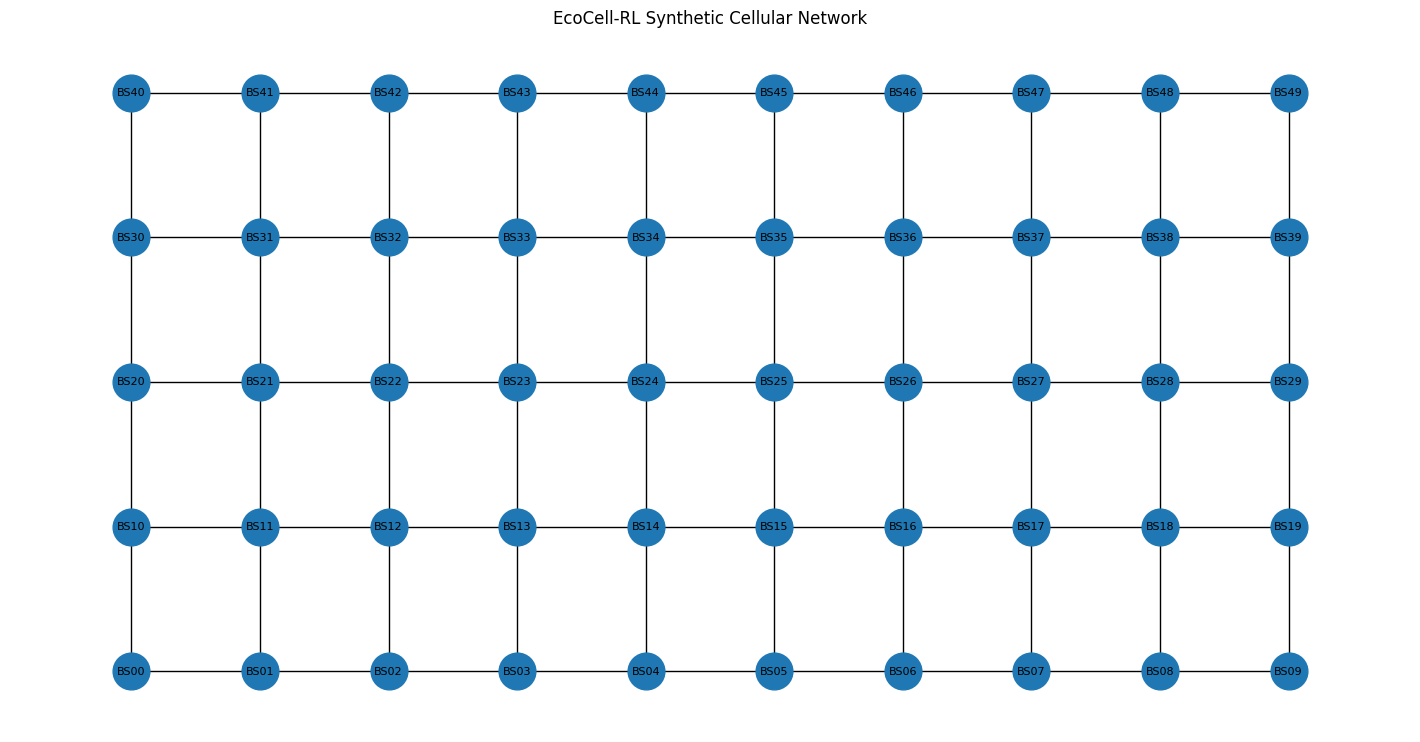

In [ ]:
plt.figure(figsize=(14, 7))

positions = {
    row["bs_id"]: (row["x"], row["y"])
    for _, row in network_df.iterrows()
}

nx.draw(
    G,
    pos=positions,
    with_labels=True,
    node_size=700,
    font_size=8
)

plt.title("EcoCell-RL Synthetic Cellular Network")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.show()

In [ ]:
bs_id = "BS12"

print("Base station:", bs_id)
print("Properties:")

for key, value in G.nodes[bs_id].items():
    print(f"{key}: {value}")

Base station: BS12
Properties:
x: 2
y: 1
cell_type: rural
capacity_mbps: 914.3687545759647
coverage_radius_km: 1.9156371828110876
baseline_power_w: 1243.4707975326264


In [ ]:
neighbors = list(G.neighbors("BS12"))

print("Neighbors of BS12:")
print(neighbors)

Neighbors of BS12:
['BS02', 'BS11', 'BS13', 'BS22']


In [ ]:
for node1, node2 in G.edges():

    x1, y1 = positions[node1]
    x2, y2 = positions[node2]

    distance = np.sqrt(
        (x1 - x2)**2 +
        (y1 - y2)**2
    )

    G[node1][node2]["distance"] = distance

print(G["BS12"]["BS13"])

{'distance': np.float64(1.0)}


In [ ]:
network_df.to_csv(
    "ecocell_network.csv",
    index=False
)

print("Network metadata saved successfully.")

Network metadata saved successfully.


In [ ]:
import os

print(os.listdir())

['.config', 'ecocell_network.csv', 'sample_data']


In [ ]:
!git clone[https://github.com/Bryan-Kweku-Wilson/Machine-Learning-Projects.git](https://github.com/Bryan-Kweku-Wilson/Machine-Learning-Projects.git)

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `git clone[https://github.com/Bryan-Kweku-Wilson/Machine-Learning-Projects.git](https://github.com/Bryan-Kweku-Wilson/Machine-Learning-Projects.git)'
